# Baseline Models & Time Series Framing

In [1]:
# Baseline Forecasting for regional‑mean SLA (5–25 °N, 65–92 °E)

import numpy as np
import pandas as pd
import xarray as xr

# --- ML / stats ---
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

# --- Utilities ---
import joblib
import matplotlib.pyplot as plt


In [2]:
#Load NetCDF ► build & scale the 1‑D series
# Path to the CMEMS DT SLA file
nc_path = r"C:\Users\Shyam\Downloads\dt_global_satellite_sla_199302_202305.nc"

ds = xr.open_dataset(nc_path)                      # NetCDF → xarray Dataset

# 5–25 °N, 65–92 °E regional mean
sla_da = (ds['sla']
          .sel(latitude=slice(5, 25),
               longitude=slice(65, 92))
          .mean(dim=['latitude', 'longitude'],
                skipna=True))

sla_df = sla_da.to_dataframe(name='sla').dropna()
sla_df.index.name = 'time'

# Scale (μ=0, σ=1); for later inverse‑transform
scaler = StandardScaler()
sla_df['sla_scaled'] = scaler.fit_transform(sla_df[['sla']])
joblib.dump(scaler, 'scaler.pkl')

print(sla_df.head())


                 sla  sla_scaled
time                            
1993-02-15  0.017730   -0.658764
1993-03-15  0.017839   -0.656432
1993-04-15  0.022611   -0.554148
1993-05-15  0.047640   -0.017661
1993-06-15  0.024242   -0.519170


In [3]:
## Train‑test split: 80 % train, 20 % test
y_full = sla_df['sla_scaled'].values
split_idx = int(0.8 * len(y_full))      # 80 % train

y_train, y_test = y_full[:split_idx], y_full[split_idx:]
print(f"Train points: {len(y_train)}, Test points: {len(y_test)}")


Train points: 291, Test points: 73


In [4]:
# Naïve forecast
# Forecast today = yesterday
y_hat_naive = np.concatenate([[np.nan], y_test[:-1]])

mae_naive  = mean_absolute_error(y_test[1:], y_hat_naive[1:])
rmse_naive = root_mean_squared_error(y_test[1:], y_hat_naive[1:])

print(f"Naïve MAE = {mae_naive:.4f}, RMSE = {rmse_naive:.4f}")
np.save('naive_pred.npy', y_hat_naive)


Naïve MAE = 0.3238, RMSE = 0.3935


In [5]:
#Moving‑average baseline (window k = 7)
k = 7
y_hat_ma = pd.Series(y_test).rolling(window=k).mean().to_numpy()

mae_ma  = mean_absolute_error(y_test[k:], y_hat_ma[k:])
rmse_ma = root_mean_squared_error(y_test[k:], y_hat_ma[k:])

print(f"MA({k}) MAE = {mae_ma:.4f}, RMSE = {rmse_ma:.4f}")
np.save(f'ma_k{k}_pred.npy', y_hat_ma)


MA(7) MAE = 0.5131, RMSE = 0.5916


In [6]:
# ARIMA(p,d,q) baseline         
arima_order = (1, 0, 0)
arima_model = ARIMA(y_train, order=arima_order).fit()

y_hat_arima = arima_model.forecast(steps=len(y_test))

mae_arima  = mean_absolute_error(y_test, y_hat_arima)
rmse_arima = root_mean_squared_error(y_test, y_hat_arima)

print(f"ARIMA{arima_order} MAE = {mae_arima:.4f}, RMSE = {rmse_arima:.4f}")
joblib.dump(arima_model, f'arima{arima_order}_model.pkl')


ARIMA(1, 0, 0) MAE = 1.2762, RMSE = 1.4464


['arima(1, 0, 0)_model.pkl']

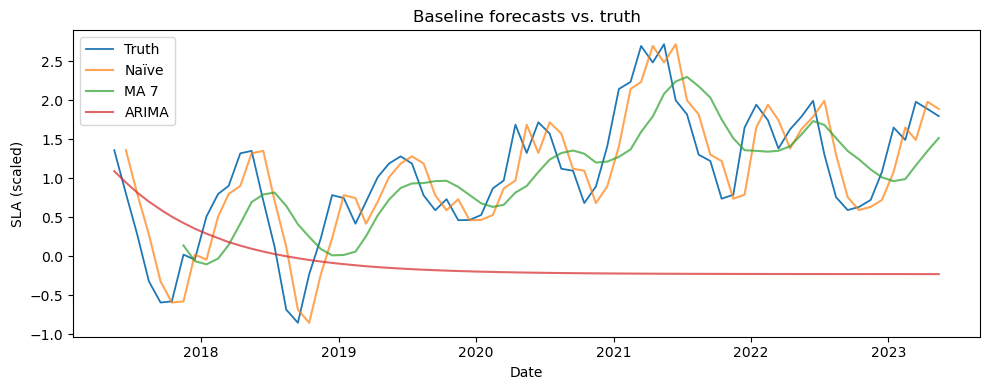

In [7]:
#Forecast the exact length of the test set
dates_test = sla_df.index[split_idx:]

plt.figure(figsize=(10, 4))
plt.plot(dates_test, y_test,        label='Truth',  linewidth=1.3)
plt.plot(dates_test, y_hat_naive,   label='Naïve',  alpha=0.7)
plt.plot(dates_test, y_hat_ma,      label=f'MA {k}', alpha=0.7)
plt.plot(dates_test, y_hat_arima,   label='ARIMA',  alpha=0.7)
plt.title('Baseline forecasts vs. truth')
plt.xlabel('Date');  plt.ylabel('SLA (scaled)')
plt.legend(); plt.tight_layout(); plt.show()



In [8]:
#summary table 
import pandas as pd
summary = pd.DataFrame({
    'MAE' : [mae_naive, mae_ma, mae_arima],
    'RMSE': [rmse_naive, rmse_ma, rmse_arima],
}, index=['Naïve', f'MA({k})', f'ARIMA{arima_order}'])
print('\nBaseline performance (test set):')
print(summary.round(4))



Baseline performance (test set):
                   MAE    RMSE
Naïve           0.3238  0.3935
MA(7)           0.5131  0.5916
ARIMA(1, 0, 0)  1.2762  1.4464


In [9]:
#Convert the 1‑D series to a supervised table
import pandas as pd
import numpy as np

def series_to_supervised(y, n_in: int, horizon: int = 1) -> pd.DataFrame:
    """
    Transform a 1‑D NumPy array or pandas Series `y`
    into a supervised‑learning DataFrame.

    Each row:
        X_1 … X_n_in   y_target
       ------------------------
        y[t‑n_in] … y[t‑1]   y[t + horizon]
    """
    if isinstance(y, pd.Series):
        y = y.values
    
    # Build a dict of shifted columns
    data = {}
    for i in range(n_in, 0, -1):
        data[f"lag_{i}"] = np.roll(y, i)   # past values (inputs)
    data["target"] = np.roll(y, -horizon)  # future value (label)
    
    df = pd.DataFrame(data)
    
    # Drop the first n_in rows and last horizon rows where rolls wrapped
    df = df.iloc[n_in : -horizon].reset_index(drop=True)
    return df


In [10]:
N = 14          # past two weeks
H = 1           # predict tomorrow
df_sup = series_to_supervised(sla_df['sla_scaled'], n_in=N, horizon=H)
print(df_sup.head())


     lag_14    lag_13    lag_12    lag_11    lag_10     lag_9     lag_8  \
0 -0.658764 -0.656432 -0.554148 -0.017661 -0.519170 -1.171004 -1.634426   
1 -0.656432 -0.554148 -0.017661 -0.519170 -1.171004 -1.634426 -1.460924   
2 -0.554148 -0.017661 -0.519170 -1.171004 -1.634426 -1.460924 -1.590925   
3 -0.017661 -0.519170 -1.171004 -1.634426 -1.460924 -1.590925 -1.221616   
4 -0.519170 -1.171004 -1.634426 -1.460924 -1.590925 -1.221616 -0.576166   

      lag_7     lag_6     lag_5     lag_4     lag_3     lag_2     lag_1  \
0 -1.460924 -1.590925 -1.221616 -0.576166  0.069579 -0.106710 -0.224625   
1 -1.590925 -1.221616 -0.576166  0.069579 -0.106710 -0.224625 -0.029279   
2 -1.221616 -0.576166  0.069579 -0.106710 -0.224625 -0.029279  0.004596   
3 -0.576166  0.069579 -0.106710 -0.224625 -0.029279  0.004596 -0.723991   
4  0.069579 -0.106710 -0.224625 -0.029279  0.004596 -0.723991 -1.051570   

     target  
0  0.004596  
1 -0.723991  
2 -1.051570  
3 -1.725806  
4 -1.778390  


In [11]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt

def root_mean_squared_error(y_true, y_pred):
    return sqrt(mean_squared_error(y_true, y_pred))

def mae_rmse(true, pred):
    """Return (MAE, RMSE) after dropping NaNs in pred."""
    mask = ~np.isnan(pred)
    return (mean_absolute_error(true[mask], pred[mask]),
            root_mean_squared_error(true[mask], pred[mask]))


# 1.    PUT YOUR REAL DATA HERE  

# y_test      = np.asarray(...)      # 1‑D array of true targets
# dates_test  = np.asarray(...)      # 1‑D array of corresponding dates
# y_hat_arima = np.asarray(...)      # 1‑D array of ARIMA predictions



np.random.seed(42)
N_TOTAL  = 30
k        = 7                         # moving‑average window
y_full   = np.cumsum(np.random.randn(N_TOTAL))
dates    = pd.date_range("2020-01-01", periods=N_TOTAL)
split    = int(2*N_TOTAL/3)
y_test   = y_full[split:]
dates_test = dates[split:]
y_hat_arima = y_test + np.random.normal(0, 0.4, len(y_test))
# 🟡 End placeholder

# ---------------- 2. Baselines -------------------------
y_hat_naive           = np.empty_like(y_test, dtype=float)
y_hat_naive[0]        = np.nan
y_hat_naive[1:]       = y_test[:-1]

y_hat_ma = (
    pd.Series(y_test)
      .rolling(window=k, min_periods=k)
      .mean()
      .to_numpy()
)

# Pad/trim ARIMA if length mismatch
if len(y_hat_arima) < len(y_test):
    y_hat_arima = np.concatenate([np.full(len(y_test)-len(y_hat_arima), np.nan),
                                  y_hat_arima])
elif len(y_hat_arima) > len(y_test):
    y_hat_arima = y_hat_arima[-len(y_test):]

# ---------------- 3. Metrics ---------------
mae_naive, rmse_naive = mae_rmse(y_test, y_hat_naive)
mae_ma,    rmse_ma    = mae_rmse(y_test, y_hat_ma)
mae_arima, rmse_arima = mae_rmse(y_test, y_hat_arima)

df_metrics = pd.DataFrame(
    {"MAE":  [mae_naive, mae_ma, mae_arima],
     "RMSE": [rmse_naive, rmse_ma, rmse_arima]},
    index=["Naïve", f"MA({k})", "ARIMA(1,0,0)"]
).round(4)

print("\n✅ Baseline accuracy on the hold‑out set:")
print(df_metrics)



✅ Baseline accuracy on the hold‑out set:
                 MAE    RMSE
Naïve         0.5325  0.6917
MA(7)         1.2822  1.3246
ARIMA(1,0,0)  0.3705  0.4519


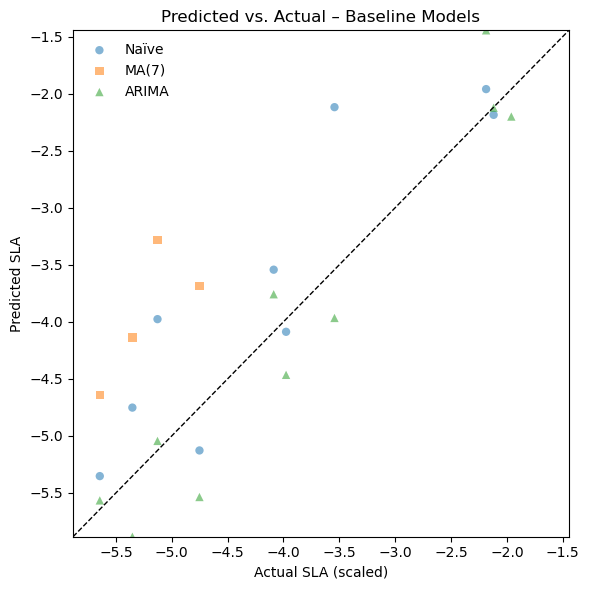

In [12]:
#  --- Predicted‑vs‑Actual scatter ------------
plt.figure(figsize=(6, 6))

# Helper: drop points where the prediction is NaN
def clean_pair(true, pred):
    m = ~np.isnan(pred)
    return true[m], pred[m]

# Scatter for each baseline
markers = {"Naïve": "o", f"MA({k})": "s", "ARIMA": "^"}
pairs   = [
    ("Naïve",  *clean_pair(y_test, y_hat_naive)),
    (f"MA({k})", *clean_pair(y_test, y_hat_ma)),
    ("ARIMA",  *clean_pair(y_test, y_hat_arima)),
]

for label, y_true_c, y_pred_c in pairs:
    plt.scatter(y_true_c, y_pred_c, alpha=0.55,
                label=label, marker=markers[label], edgecolors="none")

# Identity (perfect) line
lims = [min(np.nanmin(y_test), np.nanmin(y_hat_arima)),
        max(np.nanmax(y_test), np.nanmax(y_hat_arima))]
plt.plot(lims, lims, ls="--", lw=1, color="black")
plt.xlim(lims); plt.ylim(lims)

plt.xlabel("Actual SLA (scaled)")
plt.ylabel("Predicted SLA")
plt.title("Predicted vs. Actual – Baseline Models")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()
